In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/retail_sales_dataset.csv')

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (1000, 9)


In [2]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
print("Column Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)


Column Names:
Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

Data Types:
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object


In [4]:
print("Null Values:")
print(df.isnull().sum())

Null Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [5]:
# Select numerical columns
numerical_columns = df.select_dtypes(include='number').columns

print("Numerical Columns:")
print(list(numerical_columns))

# Mean
print("\nMean:")
print(df[numerical_columns].mean())

# Median
print("\nMedian:")
print(df[numerical_columns].median())

# Mode
print("\nMode:")
print(df[numerical_columns].mode().iloc[0])

# Standard Deviation
print("\nStandard Deviation:")
print(df[numerical_columns].std())

Numerical Columns:
['Transaction ID', 'Age', 'Quantity', 'Price per Unit', 'Total Amount']

Mean:
Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

Median:
Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

Mode:
Transaction ID     1.0
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64

Standard Deviation:
Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64


In [6]:
df['Date'] = pd.to_datetime(df['Date'])

print(df['Date'].dtype)
print(df[['Date', 'Total Amount']].head())


datetime64[ns]
        Date  Total Amount
0 2023-11-24           150
1 2023-02-27          1000
2 2023-01-13            30
3 2023-05-21           500
4 2023-05-06           100


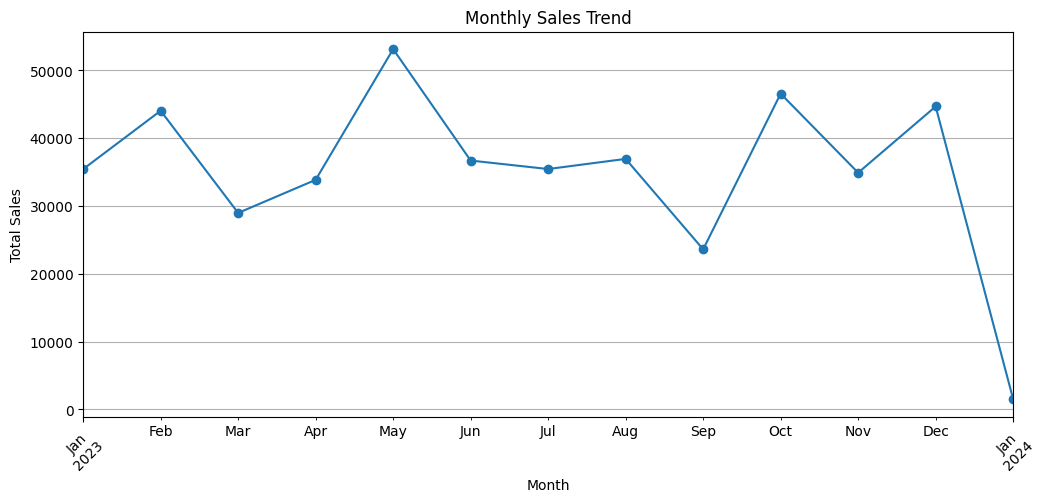

In [7]:
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()

plt.figure(figsize=(12, 5))
monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Observation

The monthly sales trend shows how total sales change over time. The highest sales month indicates a period of strong customer purchasing activity, while lower sales months may require promotional campaigns to improve sales.


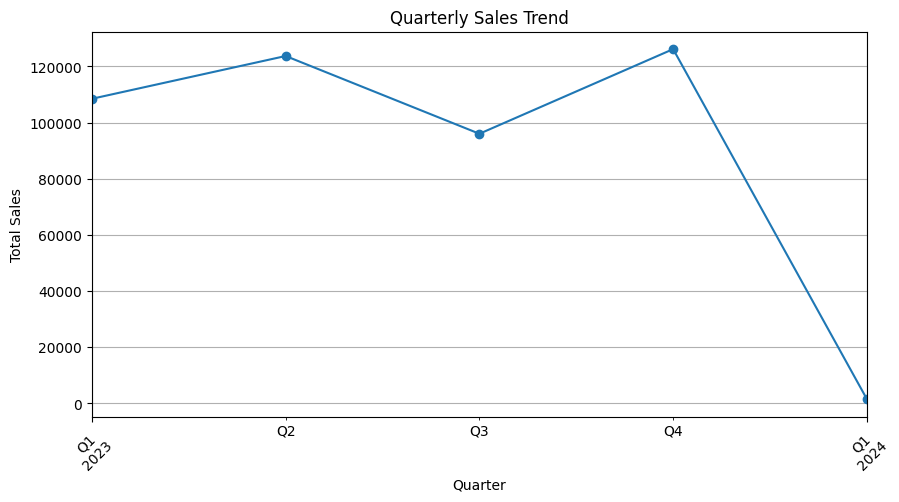

In [8]:
# Quarterly sales trend

quarterly_sales = df.groupby(df['Date'].dt.to_period('Q'))['Total Amount'].sum()

plt.figure(figsize=(10, 5))
quarterly_sales.plot(kind='line', marker='o')

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Observation

The quarterly sales trend shows the overall sales performance across different quarters. Higher sales in a quarter indicate stronger customer demand, while lower sales may require better marketing strategies and promotional offers.

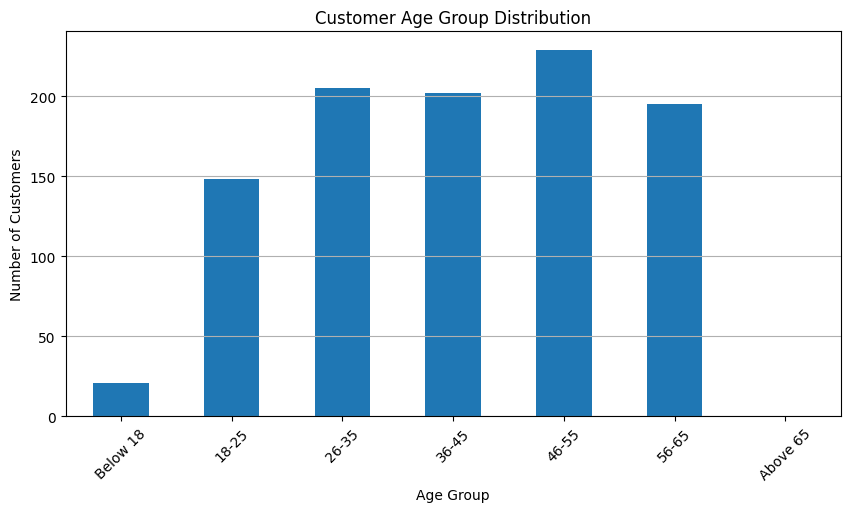

In [9]:
# Create age groups

bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['Below 18', '18-25', '26-35', '36-45', '46-55', '56-65', 'Above 65']

df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

age_group_count = df['Age Group'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
age_group_count.plot(kind='bar')

plt.title('Customer Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

### Observation

The age group distribution shows the number of customers belonging to different age groups. This analysis helps identify the major customer age segments and can help businesses design suitable products and marketing strategies for different age groups.

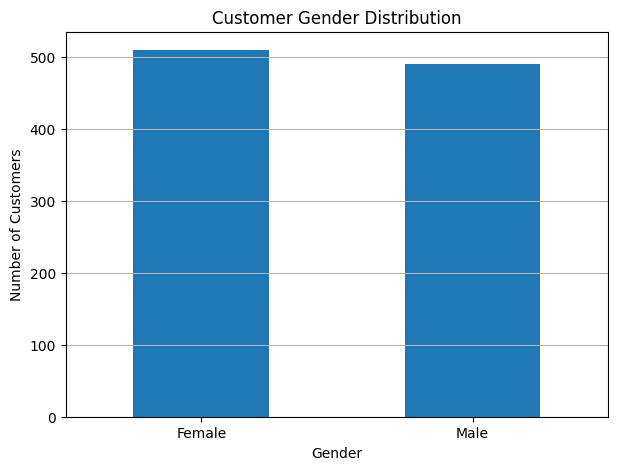

In [10]:
# Gender distribution

gender_count = df['Gender'].value_counts()

plt.figure(figsize=(7, 5))
gender_count.plot(kind='bar')

plt.title('Customer Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()


### Observation

The gender distribution shows the number of male and female customers in the dataset. This analysis helps understand the customer composition and can support gender-specific marketing and promotional strategies.

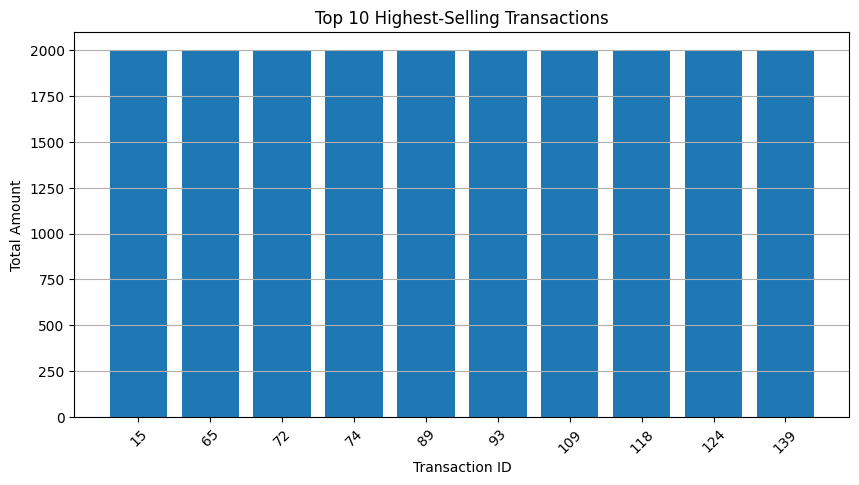

In [11]:
# Top 10 highest-selling transactions

top_10_sales = df.nlargest(10, 'Total Amount')

plt.figure(figsize=(10, 5))
plt.bar(
    top_10_sales['Transaction ID'].astype(str),
    top_10_sales['Total Amount']
)

plt.title('Top 10 Highest-Selling Transactions')
plt.xlabel('Transaction ID')
plt.ylabel('Total Amount')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

### Observation

The top 10 highest-selling transactions represent the transactions with the greatest total purchase amounts. These transactions indicate periods of high-value customer purchases and can help the business identify opportunities for increasing high-value sales.

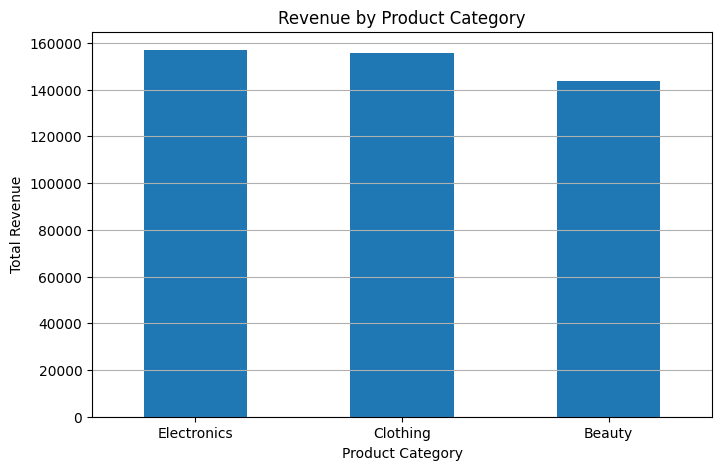

In [12]:
# Revenue by product category

category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
category_revenue.plot(kind='bar')

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

### Observation

The revenue by product category shows which product categories generate the highest total sales. Categories with higher revenue are important contributors to the business, while lower-revenue categories may need additional promotions or improved marketing strategies.

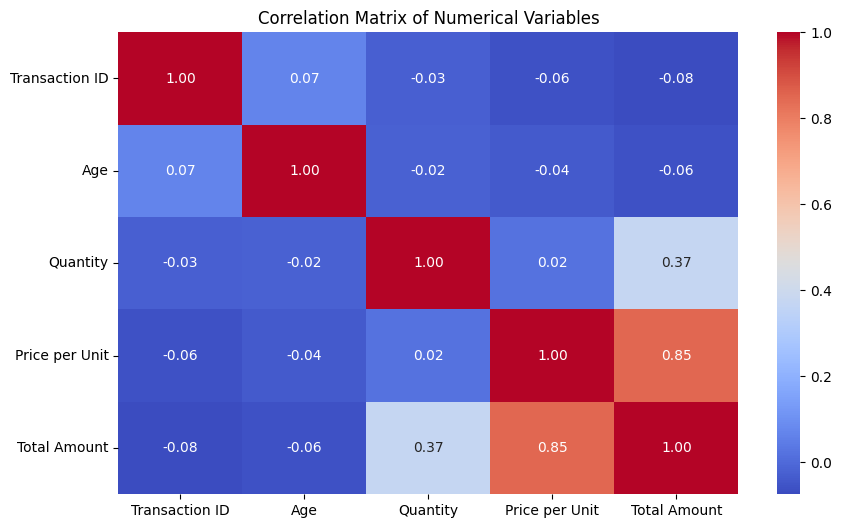

In [13]:

# Correlation matrix

correlation_matrix = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Variables')
plt.show()


### Observation

The correlation heatmap shows the relationship between the numerical variables in the dataset. A positive correlation indicates that two variables tend to increase together, while a negative correlation indicates an inverse relationship. The heatmap helps identify important relationships among quantity, price, age, and total amount.

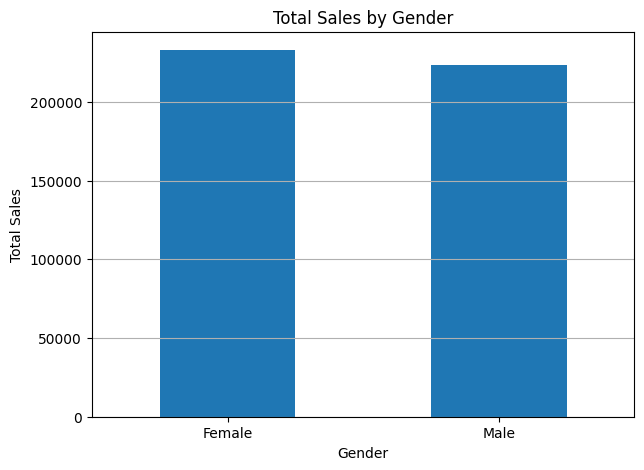

In [14]:
# Total sales by gender

gender_sales = df.groupby('Gender')['Total Amount'].sum()

plt.figure(figsize=(7, 5))
gender_sales.plot(kind='bar')

plt.title('Total Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

### Observation

The total sales by gender visualization compares the contribution of male and female customers to overall revenue. The difference in sales between genders can help the business understand customer purchasing behaviour and plan targeted marketing strategies.

## Conclusion

The Exploratory Data Analysis of the retail sales dataset helped identify important patterns in sales, customer behaviour, and product categories.

### Business Recommendations

1. **Focus on high-revenue product categories:** The business should maintain sufficient stock and promote categories that generate higher revenue.

2. **Target major customer age groups:** Marketing campaigns and offers should be designed according to the age groups that contribute most to customer purchases.

3. **Improve sales during low-performing periods:** The business should introduce discounts, seasonal offers, and promotional campaigns during months or quarters with lower sales.

4. **Increase high-value purchases:** The business can use targeted offers, product bundles, and loyalty programs to encourage customers to make higher-value purchases.